In [1]:
# Standard library
import sys
from pathlib import Path
from dataclasses import dataclass, field

# Numerical computing
import numpy as np
from scipy.optimize import curve_fit, least_squares

# Visualization
import matplotlib.pyplot as plt

# Data handling
from tqdm import tqdm

# Project imports
REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "code"))

from config import (
    MNIST_LENS_DIR,
    MPEG7_LENS_DIR,
    FIGURE_DIR,
)

In [2]:
import matplotlib as mpl

scale = 1
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.titlesize": 8 * scale,
        "axes.labelsize": 8 * scale,
        "xtick.labelsize": 7 * scale,
        "ytick.labelsize": 7 * scale,
        "legend.fontsize": 7 * scale,
        "axes.linewidth": 0.7 * scale,
        "grid.linewidth": 0.5 * scale,
        "xtick.major.width": 0.6 * scale,
        "ytick.major.width": 0.6 * scale,
        "xtick.minor.width": 0.5 * scale,
        "ytick.minor.width": 0.5 * scale,
        "lines.linewidth": 0.5 * scale,
        "lines.markeredgewidth": 0.5 * scale,
        "lines.markersize": 2.5 * scale,
        "lines.marker": "o",
        "savefig.bbox": None,
        "savefig.pad_inches": 0.0 * scale,
    }
)


def adjust_fixed_margins(fig, left_in=0.55, right_in=0.08, bottom_in=0.45, top_in=0.18):
    """
    fix margins in inch：left/right/bottom/top
    """
    W, H = fig.get_size_inches()
    fig.subplots_adjust(
        left=left_in / W,
        right=1 - right_in / W,
        bottom=bottom_in / H,
        top=1 - top_in / H,
    )

In [3]:
fig_dir = FIGURE_DIR / "supp_EMCCDCalibration"
fig_dir.mkdir(parents=True, exist_ok=True)

# Shared Processing Code

In [4]:
"""Dataset-level abstraction: each DatasetSpec fully describes one acquisition."""

@dataclass
class DatasetSpec:
    name: str  # human label, e.g. "mnist_low"
    frames_dir: Path  # folder containing per-image .npz files
    dark_frames_path: Path  # background .npz
    n_images: int  # number of images in the dataset
    n_frames: int = 100  # frames per image
    frame_shape: tuple = (45, 45)  # (H, W)
    frame_filename_template: str = "{i}_EM_Gain_200.npz"

    # Bin configuration for the variance-vs-mean fit
    bin_centers: np.ndarray = field(default_factory=lambda: np.arange(6, 66) * 100)
    bin_half_width: float = 50.0

    # Dark-noise fit range (can be left as defaults most of the time)
    dark_hist_range: tuple = (500, 1300)
    dark_n_bins: int = 400
    dark_n_sigma: int = 3
    dark_gaussian_fit_window: tuple = (530, 650)
    dark_tail_fit_window: tuple = (650, 850)

    # Robust calibration options
    rng_seed: int = 0
    traces_per_bin: int = 100
    n_bootstrap: int = 500
    trace_qc: bool = True
    trace_var_z: float = 8.0
    min_traces_after_qc: int = 20
    exclude_outlier_bins: bool = False
    outlier_z_clip: float = 5.0

    @property
    def n_pixels_per_frame(self) -> int:
        return self.frame_shape[0] * self.frame_shape[1]

In [5]:
def log_gaussian_plus_exp_tail(x, offset, sigma, amplitude, tail_slope, tail_intercept):
    gaussian = amplitude * np.exp(-0.5 * ((x - offset) / sigma) ** 2)
    tail = np.exp(tail_slope * x + tail_intercept) * (x >= offset)
    return np.log(gaussian + tail)


def fit_dark_noise(
    dark_frames,
    hist_range=(500, 1300),
    n_bins=400,
    n_sigma=3,
    initial_guess=(604, 18, 7500, -0.022, 19.27),
    gaussian_fit_window=(530, 650),
    tail_fit_window=(650, 850),
):
    """Fit the Gaussian+exp model to a stack of dark frames.

    Parameters
    ----------
    gaussian_fit_window : (lo, hi)
        Range of measured values used to constrain the Gaussian readout peak.
    tail_fit_window : (lo, hi)
        Range of measured values used to constrain the exponential CIC tail.
    """
    values = dark_frames.flatten()
    counts, edges = np.histogram(values, bins=n_bins, range=hist_range)
    centers = 0.5 * (edges[:-1] + edges[1:])

    gauss_lo, gauss_hi = gaussian_fit_window
    tail_lo, tail_hi = tail_fit_window
    fit_mask = ((centers > gauss_lo) & (centers < gauss_hi)) | (
        (centers > tail_lo) & (centers < tail_hi)
    )

    popt, _ = curve_fit(
        log_gaussian_plus_exp_tail,
        centers[fit_mask],
        np.log(np.maximum(counts[fit_mask], 1)),
        p0=initial_guess,
    )
    offset, sigma, amplitude, tail_slope, tail_intercept = popt
    return {
        "offset": offset,
        "readout_sigma": sigma,
        "amplitude": amplitude,
        "tail_slope": tail_slope,
        "tail_intercept": tail_intercept,
        "threshold": offset + n_sigma * sigma,
        "n_sigma": n_sigma,
        "hist_counts": counts,
        "hist_centers": centers,
        "hist_range": hist_range,
        "n_bins": n_bins,
        "gaussian_fit_window": gaussian_fit_window,
        "tail_fit_window": tail_fit_window,
        "fit_mask": fit_mask,
        "params": popt,
    }


def plot_dark_histogram(dark_frames, fit, title, save_path=None, fig_size=(3.2, 2.3)):
    offset, sigma, thresh = fit["offset"], fit["readout_sigma"], fit["threshold"]
    a = fit["tail_slope"]
    centers = fit["hist_centers"]
    gauss_lo, gauss_hi = fit["gaussian_fit_window"]
    tail_lo, tail_hi = fit["tail_fit_window"]

    fig, ax = plt.subplots(figsize=fig_size, dpi=150)
    ax.hist(
        dark_frames.flatten(),
        bins=fit["n_bins"],
        range=fit["hist_range"],
        alpha=0.5,
        label="Background",
    )

    # Draw model curves only over their respective fit windows
    x_gauss = centers[(centers > gauss_lo) & (centers < gauss_hi)]
    x_tail = centers[(centers > tail_lo) & (centers < tail_hi)]
    ax.plot(
        x_gauss,
        np.exp(log_gaussian_plus_exp_tail(x_gauss, *fit["params"])),
        "b",
        lw=0.5,
        ms=0.5,
    )
    ax.plot(
        x_tail,
        np.exp(log_gaussian_plus_exp_tail(x_tail, *fit["params"])),
        "r",
        lw=0.5,
        ms=0.5,
    )

    ax.axvline(thresh, color="g", ls="--", lw=0.5)
    ax.text(
        offset + 6 * sigma,
        0.1 * fit["hist_counts"].max(),
        f"$\\mu={offset:.0f}, \\sigma={sigma:.0f}$\n threshold $={thresh:.0f}$",
        ha="left",
        fontsize=7,
    )
    ax.text(
        offset + 9 * sigma,
        20,
        f"slope = {a:.3f}\n 1/$|$slope$|$ = {1/abs(a):.2f}",
        ha="left",
        fontsize=7,
    )

    ax.set_yscale("log")
    ax.set_ylim(0.8, 2.5e4)
    ax.set_xlabel(r"Measured value ($\mathrm{gl}$)")
    ax.set_ylabel("Frequency: number of pixels")
    ax.set_title(title)

    fig.tight_layout()
    adjust_fixed_margins(fig, left_in=0.45, bottom_in=0.35, right_in=0.15, top_in=0.18)
    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches=None, pad_inches=0.0)
    return fig, ax


def save_background(save_path, fit):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        save_path,
        params=fit["params"],
        offset=fit["offset"],
        readout_sigma=fit["readout_sigma"],
        tail_slope=fit["tail_slope"],
        threshold=fit["threshold"],
    )

In [6]:
def load_image_stack(spec: DatasetSpec):
    """Load frames for a single dataset, return (time_mean, time_raw)."""
    n_pixels = spec.n_pixels_per_frame
    time_mean_list, time_raw_list = [], []
    for i in tqdm(range(spec.n_images), desc=f"loading {spec.name}"):
        fname = spec.frame_filename_template.format(i=i)
        frames = np.load(spec.frames_dir / fname)["data"]  # (n_frames, H, W)
        time_mean_list.append(frames.mean(axis=0).reshape(-1))
        time_raw_list.append(frames.reshape(spec.n_frames, n_pixels).T)
    return (np.concatenate(time_mean_list), np.concatenate(time_raw_list, axis=0))


def _trace_qc_mask(
    traces,
    trace_var_z=8.0,
    saturation_level=65000,
):
    traces = np.asarray(traces, dtype=float)
    pair_vars = traces.var(axis=1, ddof=1)
    log_vars = np.log(pair_vars + 1.0)

    med = np.nanmedian(log_vars)
    mad = np.nanmedian(np.abs(log_vars - med))
    scale = 1.4826 * mad

    mask = np.isfinite(pair_vars)
    mask &= np.nanmax(traces, axis=1) < saturation_level

    # Upper-tail only. Do not remove unusually low-variance traces.
    if np.isfinite(scale) and scale > 0:
        mask &= log_vars <= med + trace_var_z * scale

    return mask


def _hierarchical_bootstrap_mean_var(
    traces,
    n_bootstrap=2000,
    rng=None,
):
    """Bootstrap SE of bin mean and bin variance.

    traces has shape (P, S), where P is the number of pixel-input traces
    in one mean bin and S is the number of frames per trace.

    Bootstrap hierarchy:
    1. resample traces;
    2. resample frames within each selected trace;
    3. recompute mean of trace means and mean of trace variances.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    traces = np.asarray(traces, dtype=float)
    P, S = traces.shape

    boot_means = np.empty(n_bootstrap)
    boot_vars = np.empty(n_bootstrap)

    for b in range(n_bootstrap):
        trace_idx = rng.integers(0, P, size=P)
        sampled = traces[trace_idx]

        frame_idx = rng.integers(0, S, size=(P, S))
        sampled = np.take_along_axis(sampled, frame_idx, axis=1)

        pair_means = sampled.mean(axis=1)
        pair_vars = sampled.var(axis=1, ddof=1)

        boot_means[b] = pair_means.mean()
        boot_vars[b] = pair_vars.mean()

    return boot_means.std(ddof=1), boot_vars.std(ddof=1)


def group_by_mean(
    pixel_time_mean,
    pixel_time_raw,
    bin_centers,
    half_width,
    traces_per_bin=500,
    rng_select=None,
    rng_bootstrap=None,
    n_bootstrap=2000,
    trace_qc=False,
    trace_var_z=8.0,
    min_traces_after_qc=20,
):
    """Group pixel-input traces by mean ADU and estimate calibration points.

    Returns
    -------
    centers_kept : array
        Bin centers.
    means : array
        Mean ADU of each calibration bin, estimated as average trace mean.
    variances : array
        Mean within-trace frame variance of each bin.
    var_sem : array
        Bootstrap standard error of the bin variance.
    diagnostics : list[dict]
        Per-bin diagnostic information.
    """

    if rng_select is None:
        rng_select = np.random.default_rng(0)
    if rng_bootstrap is None:
        rng_bootstrap = np.random.default_rng(1)

    kept, means, variances, var_sem = [], [], [], []
    diagnostics = []

    for center in bin_centers:
        idx = np.where(
            (pixel_time_mean >= center - half_width)
            & (pixel_time_mean < center + half_width)
        )[0]

        if idx.size < min_traces_after_qc:
            continue

        n_pick = min(traces_per_bin, idx.size)
        chosen = rng_select.choice(idx, size=n_pick, replace=False)

        traces = np.asarray(pixel_time_raw[chosen], dtype=float)  # shape (P, S)

        qc_mask = np.ones(traces.shape[0], dtype=bool)
        if trace_qc:
            qc_mask = _trace_qc_mask(traces, trace_var_z=trace_var_z)

            # Avoid making a bin from too few traces.
            # If QC would remove too much, keep the bin unfiltered but record it.
            if qc_mask.sum() < min_traces_after_qc:
                qc_mask = np.ones(traces.shape[0], dtype=bool)

        traces_qc = traces[qc_mask]

        pair_means = traces_qc.mean(axis=1)
        pair_vars = traces_qc.var(axis=1, ddof=1)

        bin_mean = pair_means.mean()
        bin_var = pair_vars.mean()

        mean_se, var_se = _hierarchical_bootstrap_mean_var(
            traces_qc,
            n_bootstrap=n_bootstrap,
            rng=rng_bootstrap,
        )

        kept.append(center)
        means.append(bin_mean)
        variances.append(bin_var)
        var_sem.append(max(var_se, 1e-12))

        diagnostics.append(
            {
                "center": center,
                "n_candidates": idx.size,
                "chosen_indices": chosen,
                "qc_mask": qc_mask,
                "n_used": int(qc_mask.sum()),
                "pair_means": pair_means,
                "pair_vars": pair_vars,
                "pair_max": traces_qc.max(axis=1),
                "bin_mean_sem": mean_se,
                "bin_var_sem": var_se,
            }
        )

    return (
        np.asarray(kept),
        np.asarray(means),
        np.asarray(variances),
        np.asarray(var_sem),
        diagnostics,
    )


@dataclass
class LinearFit:
    slope: float
    intercept: float
    slope_err: float
    intercept_err: float
    r_squared: float


def weighted_linear_fit(x, y, y_sem, error_scale=1.0) -> LinearFit:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_sem = np.asarray(y_sem, dtype=float)

    w = 1.0 / np.maximum(y_sem, 1e-12) ** 2

    S = w.sum()
    Sx = (w * x).sum()
    Sy = (w * y).sum()
    Sxx = (w * x * x).sum()
    Sxy = (w * x * y).sum()

    det = S * Sxx - Sx * Sx

    slope = (S * Sxy - Sx * Sy) / det
    intercept = (Sxx * Sy - Sx * Sxy) / det

    slope_err = np.sqrt(S / det) * error_scale
    intercept_err = np.sqrt(Sxx / det) * error_scale

    r2 = 1 - np.sum((y - slope * x - intercept) ** 2) / np.sum((y - y.mean()) ** 2)

    return LinearFit(slope, intercept, slope_err, intercept_err, r2)


def robust_weighted_linear_fit(
    x,
    y,
    y_sem,
    z_clip=5.0,
    soft_l1_f_scale=2.0,
    exclude_outlier_bins=False,
):
    """Scaled WLS with optional bin-level outlier exclusion.

    By default, no bin is excluded. A robust residual scale is estimated
    and used only to inflate the fit uncertainty. Outlier exclusion can be
    turned on explicitly for diagnostic or sensitivity analyses.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_sem = np.asarray(y_sem, dtype=float)

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(y_sem) & (y_sem > 0)
    raw_fit = weighted_linear_fit(x[finite], y[finite], y_sem[finite])

    def residual(theta):
        a, b = theta
        return (y[finite] - (a * x[finite] + b)) / y_sem[finite]

    res = least_squares(
        residual,
        x0=np.array([raw_fit.slope, raw_fit.intercept]),
        loss="soft_l1",
        f_scale=soft_l1_f_scale,
    )

    a0, b0 = res.x
    z0 = np.full_like(y, np.nan, dtype=float)
    z0[finite] = (y[finite] - (a0 * x[finite] + b0)) / y_sem[finite]

    robust_scale = 1.4826 * np.nanmedian(np.abs(z0[finite]))
    if (not np.isfinite(robust_scale)) or robust_scale < 1.0:
        robust_scale = 1.0

    flagged_mask = finite & (np.abs(z0) > z_clip * robust_scale)

    if exclude_outlier_bins:
        fit_mask = finite & ~flagged_mask

        # Safety fallback: do not allow accidental deletion of too many bins.
        if fit_mask.sum() < max(5, int(0.8 * finite.sum())):
            print(
                "Warning: outlier exclusion would remove too many bins; "
                "using all finite calibration bins instead."
            )
            fit_mask = finite.copy()
    else:
        fit_mask = finite.copy()

    final_fit = weighted_linear_fit(
        x[fit_mask],
        y[fit_mask],
        y_sem[fit_mask],
        error_scale=robust_scale,
    )

    z_final = np.full_like(y, np.nan, dtype=float)
    z_final[finite] = (
        y[finite] - (final_fit.slope * x[finite] + final_fit.intercept)
    ) / y_sem[finite]

    return final_fit, fit_mask, raw_fit, z_final, robust_scale, flagged_mask


def plot_variance_vs_mean(
    mean_gl,
    var_gl2,
    var_sem,
    fit: LinearFit,
    background_gl,
    title,
    save_path=None,
    fig_size=(3.2, 2.3),
    inlier_mask=None,
):
    gain, gain_err = fit.slope / 2.0, fit.slope_err / 2.0
    x = mean_gl - background_gl

    if inlier_mask is None:
        inlier_mask = np.ones_like(x, dtype=bool)

    fig, ax = plt.subplots(figsize=fig_size, dpi=150)

    ax.errorbar(
        x[inlier_mask],
        var_gl2[inlier_mask],
        yerr=var_sem[inlier_mask],
        fmt="o",
        ms=2.5,
        lw=0.6,
        capsize=1.5,
        color="tab:blue",
        label="data used in fit",
    )

    if np.any(~inlier_mask):
        ax.errorbar(
            x[~inlier_mask],
            var_gl2[~inlier_mask],
            yerr=var_sem[~inlier_mask],
            fmt="x",
            ms=4.0,
            lw=0.8,
            capsize=1.5,
            color="tab:red",
            label="flagged bin",
        )

    x_line = np.linspace(x[inlier_mask].min(), x[inlier_mask].max(), 100)

    ax.plot(
        x_line,
        fit.slope * x_line + fit.intercept,
        "r--",
        lw=1.0,
        label=(
            rf"fit: $\hat{{v}}=a\,(\hat{{m}}-\bar{{X}}_\text{{dark}})+b$" "\n"
            rf"$a$ = {fit.slope:.2f} ± {fit.slope_err:.2f}" "\n"
            rf"$b$ = {fit.intercept:.1f} ± {fit.intercept_err:.1f}" "\n"
            rf"$g=a/2$ = {gain:.2f} ± {gain_err:.2f}" "\n"
            rf"$R^2$ = {fit.r_squared:.4f}"
        ),
    )

    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.set_xlabel(r"Mean value $m-$ dark mean $\bar{X}_\text{dark}$ ($\mathrm{gl}$)")
    ax.set_ylabel(r"Within-trace variance $v$ ($\mathrm{gl}^2$)")
    ax.set_title(title)
    ax.grid(alpha=0.9, which="major", linestyle="--")
    ax.legend(loc="upper left", fontsize=6.5, frameon=False)

    fig.tight_layout()
    adjust_fixed_margins(
        fig,
        left_in=0.45,
        bottom_in=0.35,
        right_in=0.15,
        top_in=0.18,
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches=None, pad_inches=0.0)

    return fig, ax

In [7]:
QUANTUM_EFFICIENCY = 0.65


def estimate_photons_per_frame(
    pixel_time_mean, background_offset, gain, quantum_efficiency, n_pixels_per_frame
):
    signal_gl = pixel_time_mean - background_offset
    photons_per_pixel = signal_gl / (quantum_efficiency * gain)
    n_frames = pixel_time_mean.size // n_pixels_per_frame
    photons_per_frame = photons_per_pixel.reshape(n_frames, n_pixels_per_frame).sum(
        axis=1
    )
    return {
        "photons_per_frame": photons_per_frame,
        "mean_photons_per_frame": photons_per_frame.mean(),
        "std_photons_per_frame": photons_per_frame.std(ddof=1),
        "photons_per_pixel": photons_per_pixel,
    }

In [8]:
def process_dataset(
    spec: DatasetSpec,
    fig_dir: Path,
    quantum_efficiency=QUANTUM_EFFICIENCY,
):
    """End-to-end pipeline for one dataset. Returns everything in a dict."""
    # --- dark-frame fit ---
    dark_frames = np.load(spec.dark_frames_path)["data"]

    dark_fit = fit_dark_noise(
        dark_frames,
        hist_range=spec.dark_hist_range,
        n_bins=spec.dark_n_bins,
        n_sigma=spec.dark_n_sigma,
        gaussian_fit_window=spec.dark_gaussian_fit_window,
        tail_fit_window=spec.dark_tail_fit_window,
    )

    # dark_peak_mu and dark_peak_sigma are used only for thresholding.
    # The empirical dark mean is used for photon-budget estimation and
    # for the physical background-subtracted mean axis in the gain fit.
    dark_peak_mu = dark_fit["offset"]  # Gaussian peak center, mu
    dark_peak_sigma = dark_fit["readout_sigma"]  # Gaussian peak width
    dark_mean_global = dark_frames.mean()  # empirical dark mean, b_dark
    dark_std_global = dark_frames.std(ddof=1)

    print(f"[{spec.name}]")
    print(f"           empirical dark mean = {dark_mean_global:.2f} gl")
    print(f"           empirical dark std  = {dark_std_global:.2f} gl")
    print(f"dark-noise fit:")
    print(f"           mu peak offset  = {dark_peak_mu:.2f} gl")
    print(f"           sigma readout   = {dark_peak_sigma:.2f} gl")
    print(
        f"           tail slope      = {dark_fit['tail_slope']:.4f}  "
        f"(1/|slope| = {1/abs(dark_fit['tail_slope']):.2f} gl)"
    )
    print(
        f"           threshold (mu+{dark_fit['n_sigma']}sigma) = "
        f"{dark_fit['threshold']:.2f} gl"
    )

    plot_dark_histogram(
        dark_frames,
        dark_fit,
        title=f"{spec.name}: dark-frame histogram",
        save_path=fig_dir / f"dark_hist_{spec.name}.svg",
    )

    save_background(spec.frames_dir.parent / "background.npz", dark_fit)

    # --- load frames ---
    pixel_time_mean, pixel_time_raw = load_image_stack(spec)

    # --- variance-vs-mean fit for gain ---
    seed_sequence = np.random.SeedSequence(spec.rng_seed)
    rng_select, rng_bootstrap = [
        np.random.default_rng(s) for s in seed_sequence.spawn(2)
    ]

    centers, bin_mean, bin_var, bin_var_sem, group_diag = group_by_mean(
        pixel_time_mean,
        pixel_time_raw,
        spec.bin_centers,
        spec.bin_half_width,
        traces_per_bin=spec.traces_per_bin,
        rng_select=rng_select,
        rng_bootstrap=rng_bootstrap,
        n_bootstrap=spec.n_bootstrap,
        trace_qc=spec.trace_qc,
        trace_var_z=spec.trace_var_z,
        min_traces_after_qc=spec.min_traces_after_qc,
    )

    # Use empirical dark mean for physical photon-induced mean.
    # The slope is invariant to constant offsets, but this keeps notation consistent.
    x_cal = bin_mean - dark_mean_global

    fit, inlier_mask, raw_fit, z_resid, robust_scale, _ = robust_weighted_linear_fit(
        x_cal,
        bin_var,
        bin_var_sem,
        z_clip=spec.outlier_z_clip,
        exclude_outlier_bins=spec.exclude_outlier_bins,
    )

    plot_variance_vs_mean(
        mean_gl=bin_mean,
        var_gl2=bin_var,
        var_sem=bin_var_sem,
        fit=fit,
        background_gl=dark_mean_global,
        title=f"{spec.name}: variance vs. mean",
        save_path=fig_dir / f"var_mean_fit_{spec.name}.svg",
        inlier_mask=inlier_mask,
    )

    gain = fit.slope / 2.0
    gain_err = fit.slope_err / 2.0

    print(f"raw gain fit:")
    print(
        f"           g_raw = {raw_fit.slope/2:.2f} ± {raw_fit.slope_err/2:.2f} "
        f"(R^2 = {raw_fit.r_squared:.4f})"
    )
    if spec.exclude_outlier_bins:
        fit_name = "inlier weighted gain fit"
        r2_label = r"$R^2_\mathrm{inlier}$"
    else:
        fit_name = (
            "all-bin weighted gain fit (errors inflated by robust residual scale)"
        )
        r2_label = r"$R^2$"
    print(f"{fit_name}:")
    print(
        f"           g = {gain:.2f} ± {gain_err:.2f} "
        f"({r2_label} = {fit.r_squared:.4f}, residual_scale = {robust_scale:.2f})"
    )

    qc_total = sum(len(d["qc_mask"]) for d in group_diag)
    qc_used = sum(d["n_used"] for d in group_diag)
    qc_removed = qc_total - qc_used

    print(
        f"trace QC removed {qc_removed}/{qc_total} selected traces "
        f"({100 * qc_removed / max(qc_total, 1):.3f}%)"
    )

    excluded = np.flatnonzero(~inlier_mask)
    if excluded.size > 0:
        print(f"flagged calibration bins: {excluded.tolist()}")
        for j in excluded:
            diag = group_diag[j]
            print(
                f"  bin #{j}: center={diag['center']}, "
                f"x={x_cal[j]:.1f}, var={bin_var[j]:.1f}, "
                f"SE={bin_var_sem[j]:.1f}, z={z_resid[j]:.1f}, "
                f"n_candidates={diag['n_candidates']}, n_used={diag['n_used']}"
            )
            print(
                f"    trace variance: median={np.median(diag['pair_vars']):.1f}, "
                f"max={np.max(diag['pair_vars']):.1f}"
            )
            print(
                f"    trace max ADU: median={np.median(diag['pair_max']):.1f}, "
                f"max={np.max(diag['pair_max']):.1f}"
            )

    # --- photons per frame ---
    photons = estimate_photons_per_frame(
        pixel_time_mean=pixel_time_mean,
        background_offset=dark_mean_global,
        gain=gain,
        quantum_efficiency=quantum_efficiency,
        n_pixels_per_frame=spec.n_pixels_per_frame,
    )

    mean_n = photons["mean_photons_per_frame"]
    mean_n_err_gain_only = mean_n * (gain_err / gain)

    msg = (
        f"           incident photons/frame = {mean_n:.1f} "
        f"± {mean_n_err_gain_only:.1f} (gain-fit only)"
    )

    print(msg)
    print(
        f"           detected photoelectrons/frame = "
        f"{quantum_efficiency * mean_n:.1f}"
        f"± {quantum_efficiency * mean_n_err_gain_only:.1f} (gain-fit only)"
    )
    print(
        f"           std across input images = "
        f"{quantum_efficiency * photons['std_photons_per_frame']:.1f} detected photons"
    )

    return {
        "spec": spec,
        "dark_fit": dark_fit,
        "dark_peak_mu": dark_peak_mu,
        "dark_readout_sigma": dark_peak_sigma,
        "dark_mean_global": dark_mean_global,
        "pixel_time_mean": pixel_time_mean,
        "pixel_time_raw": pixel_time_raw,
        "calibration_centers": centers,
        "calibration_mean": bin_mean,
        "calibration_var": bin_var,
        "calibration_var_sem": bin_var_sem,
        "calibration_diag": group_diag,
        "calibration_inlier_mask": inlier_mask,
        "calibration_z_resid": z_resid,
        "raw_variance_fit": raw_fit,
        "variance_fit": fit,
        "gain": gain,
        "gain_err": gain_err,
        **photons,
        "mean_n_err_from_gain": mean_n_err_gain_only,
    }

# MNIST

[MNIST, low power]
           empirical dark mean = 605.04 gl
           empirical dark std  = 22.02 gl
dark-noise fit:
           mu peak offset  = 604.03 gl
           sigma readout   = 18.39 gl
           tail slope      = -0.0218  (1/|slope| = 45.93 gl)
           threshold (mu+3sigma) = 659.20 gl


loading MNIST, low power: 100%|██████████| 12000/12000 [00:22<00:00, 524.29it/s]


raw gain fit:
           g_raw = 54.57 ± 0.36 (R^2 = 0.9994)
all-bin weighted gain fit (errors inflated by robust residual scale):
           g = 54.57 ± 0.36 ($R^2$ = 0.9994, residual_scale = 1.00)
trace QC removed 0/2339 selected traces (0.000%)
           incident photons/frame = 51.0 ± 0.3 (gain-fit only)
           detected photoelectrons/frame = 33.1± 0.2 (gain-fit only)
           std across input images = 7.5 detected photons
[MNIST, high power]
           empirical dark mean = 606.04 gl
           empirical dark std  = 22.18 gl
dark-noise fit:
           mu peak offset  = 604.85 gl
           sigma readout   = 17.68 gl
           tail slope      = -0.0228  (1/|slope| = 43.94 gl)
           threshold (mu+3sigma) = 657.89 gl


loading MNIST, high power: 100%|██████████| 12000/12000 [00:28<00:00, 427.88it/s]


raw gain fit:
           g_raw = 58.80 ± 0.17 (R^2 = 0.9941)
all-bin weighted gain fit (errors inflated by robust residual scale):
           g = 58.80 ± 0.33 ($R^2$ = 0.9941, residual_scale = 1.88)
trace QC removed 3/5985 selected traces (0.050%)
           incident photons/frame = 1071.1 ± 5.9 (gain-fit only)
           detected photoelectrons/frame = 696.2± 3.9 (gain-fit only)
           std across input images = 28.6 detected photons


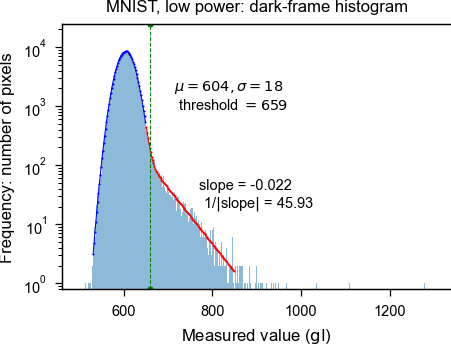

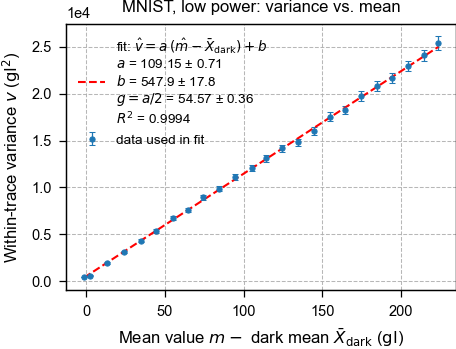

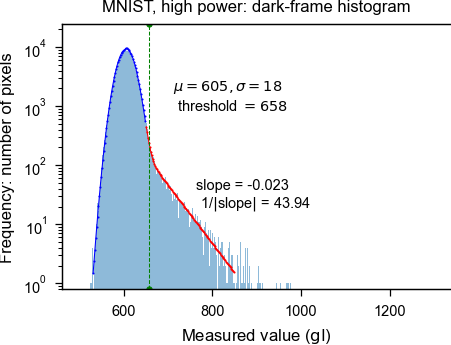

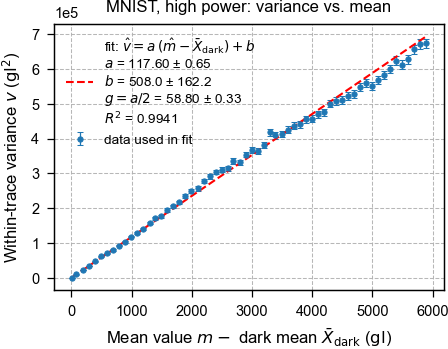

In [9]:
# --- MNIST datasets ---
mnist_low = DatasetSpec(
    name="MNIST, low power",
    frames_dir=MNIST_LENS_DIR["low"] / "frames",
    dark_frames_path=MNIST_LENS_DIR["low"]
    / "raw_dark_frames/Background_100_frames_10ms_exposure_200_EMGain.npz",
    n_images=12000,
    bin_centers=np.arange(60, 84) * 10,
    bin_half_width=5,
    traces_per_bin=100,
    n_bootstrap=2000,
)
mnist_high = DatasetSpec(
    name="MNIST, high power",
    frames_dir=MNIST_LENS_DIR["high"] / "frames",
    dark_frames_path=MNIST_LENS_DIR["high"]
    / "raw_dark_frames/Background_100_frames_10ms_exposure_200_EMGain.npz",
    n_images=12000,
    bin_centers=np.arange(6, 66) * 100,
    bin_half_width=50,
    traces_per_bin=100,
    n_bootstrap=2000,
)

# --- run ---
datasets = [mnist_low, mnist_high]
results = {spec.name: process_dataset(spec, fig_dir) for spec in datasets}

# MPEG-7

In [10]:
mpeg7 = DatasetSpec(
    name="MPEG-7",
    frames_dir=MPEG7_LENS_DIR / "frames",
    dark_frames_path=MPEG7_LENS_DIR
    / "raw_dark_frames/Background_300_frames_15ms_exposure_1000_EMGain.npz",
    n_images=1400,
    bin_centers=np.arange(6, 100) * 100,  # choose per your data range
    bin_half_width=50,
    n_frames=300,
    frame_shape=(39, 39),  # change if your camera ROI differs
    frame_filename_template="{i}_EM_Gain_1000.npz",
    dark_gaussian_fit_window=(530, 650),
    dark_tail_fit_window=(750, 1200),
    traces_per_bin=100,
    n_bootstrap=2000,
)

[MPEG-7]
           empirical dark mean = 603.19 gl
           empirical dark std  = 56.18 gl
dark-noise fit:
           mu peak offset  = 596.41 gl
           sigma readout   = 14.52 gl
           tail slope      = -0.0066  (1/|slope| = 150.52 gl)
           threshold (mu+3sigma) = 639.96 gl


loading MPEG-7: 100%|██████████| 1400/1400 [00:07<00:00, 183.38it/s]


raw gain fit:
           g_raw = 167.04 ± 0.29 (R^2 = 0.9981)
all-bin weighted gain fit (errors inflated by robust residual scale):
           g = 167.04 ± 0.35 ($R^2$ = 0.9981, residual_scale = 1.19)
trace QC removed 0/6291 selected traces (0.000%)
           incident photons/frame = 1227.0 ± 2.5 (gain-fit only)
           detected photoelectrons/frame = 797.5± 1.7 (gain-fit only)
           std across input images = 46.3 detected photons


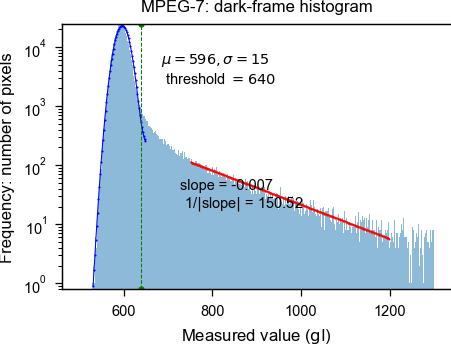

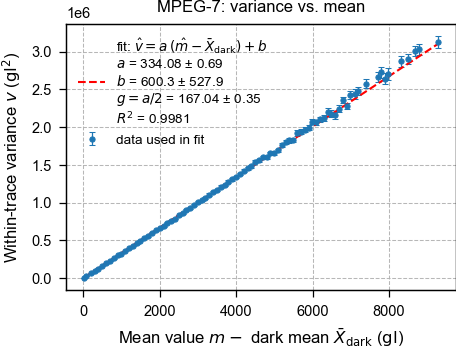

In [11]:
results[mpeg7.name] = process_dataset(mpeg7, fig_dir)